# Enterprise Email & SMS Spam Detection
**Objective:** Build a robust, scalable NLP binary classifier to distinguish spam messages from legitimate (ham) messages.

**Project Phases:**
1. Data Acquisition & Safe Loading
2. Exploratory Data Analysis (EDA) & Feature Engineering
3. Text Preprocessing Pipeline
4. TF-IDF Feature Extraction
5. Model Training (Naive Bayes & Support Vector Machine)
6. Evaluation & Strategic Discussion

## Step 1: Environment Setup & Imports
First, we import the standard libraries required for data manipulation, visualization, text processing, and machine learning. We also configure our visualization style and suppress unnecessary warnings to keep the notebook clean.

In [15]:
# Standard Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Regex and Text Processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Scikit-Learn Modules
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)

# Configuration
sns.set_theme(style="whitegrid")
nltk.download('stopwords', quiet=True)
import warnings
warnings.filterwarnings('ignore')

## Step 2: Data Acquisition & Safe Loading
Real-world datasets often contain formatting artifacts (like hidden characters in column headers or trailing spaces). To make our pipeline bulletproof, we define a custom loading function that grabs the exact columns we need by their index position (`iloc`), rather than relying on inconsistent text names. We also check for and remove duplicate records.

In [16]:
def load_and_clean_data(filepath):
    """Loads SMS dataset safely, bypassing hidden character header errors."""
    print(f"Loading data from: {filepath}...")
    df = pd.read_csv(filepath, encoding='latin-1')
    
    # Grab the first two columns strictly by index position
    df = df.iloc[:, [0, 1]]
    df.columns = ['label', 'message']
    
    # Encode target variable
    df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})
    
    # Drop any potential duplicates
    initial_shape = df.shape
    df = df.drop_duplicates(keep='first')
    print(f"Dropped {initial_shape[0] - df.shape[0]} duplicate rows.")
    
    return df

# Load the dataset
df = load_and_clean_data('spam.csv')

Loading data from: spam.csv...
Dropped 415 duplicate rows.


## Step 3: Exploratory Data Analysis (EDA) & Feature Engineering
Before training a model, we must understand our data distribution. 
* **Class Imbalance:** We will check the ratio of Spam to Ham. 
* **Feature Engineering:** We will calculate the length of each message to see if spam messages are systematically longer or shorter than normal messages.

In [10]:
df.describe()

,label_num
count,5574.000000
mean,0.134015
std,0.340699
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [11]:
df.isnull().sum()

label        0
message      0
label_num    0
dtype: int64

--- Class Distribution ---
label
ham     87.575111
spam    12.424889
Name: proportion, dtype: float64


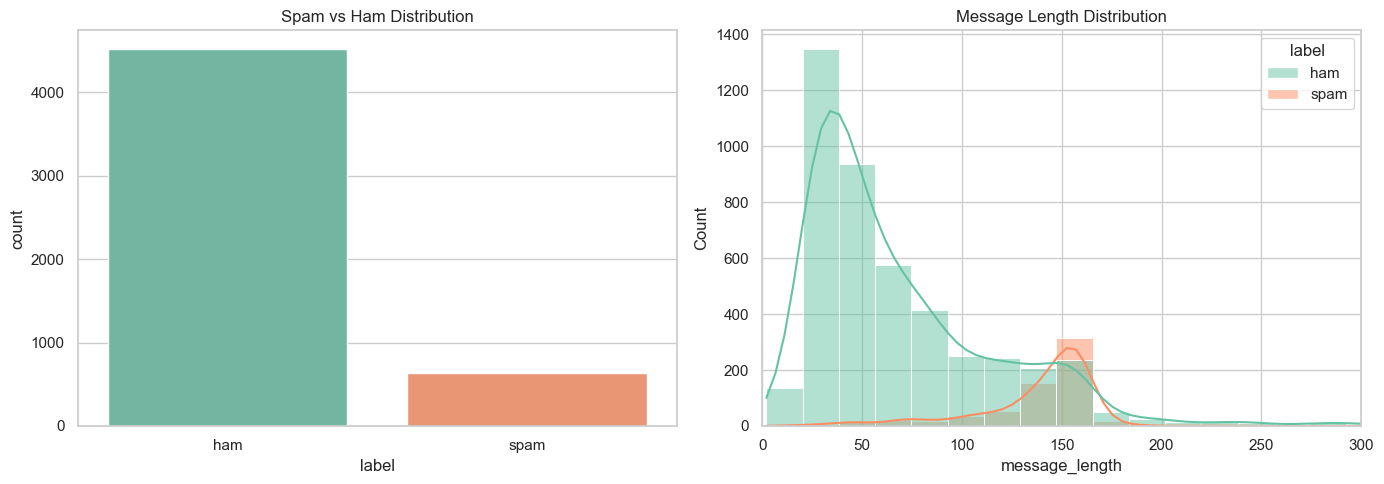

In [17]:
# 1. Class Distribution
print("--- Class Distribution ---")
print(df['label'].value_counts(normalize=True) * 100)

# 2. Feature Engineering: Message Length
df['message_length'] = df['message'].apply(len)

# 3. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
sns.countplot(data=df, x='label', palette='Set2', ax=axes[0])
axes[0].set_title("Spam vs Ham Distribution")

# Length Distribution (KDE)
sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True, palette='Set2', ax=axes[1])
axes[1].set_title("Message Length Distribution")
axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()

## Step 4: Text Preprocessing Pipeline
Machine learning models cannot read raw text; they require structured data. We will build an object-oriented `TextPreprocessor` class to normalize our text.

**The Pipeline Steps:**
1. **Lowercase Conversion:** Ensuring "Free" and "free" are treated as the same word.
2. **Punctuation Removal:** Stripping out special characters using Regular Expressions (Regex).
3. **Stopword Removal:** Filtering out common English words (like "the", "and", "is") that do not add predictive value.
4. **Stemming:** Reducing words to their root form (e.g., "running" becomes "run").

In [19]:
class TextPreprocessor:
    """Handles text normalization, stopword removal, and stemming."""
    
    def __init__(self):
        self.stemmer = PorterStemmer()
        self.stop_words = set(stopwords.words('english'))
        
    def clean_text(self, text):
        # Lowercase
        text = str(text).lower()
        # Remove punctuation and numbers
        text = re.sub(r'[^a-z\s]', '', text)
        # Tokenize, remove stopwords, and stem
        words = [self.stemmer.stem(w) for w in text.split() if w not in self.stop_words]
        return ' '.join(words)

# Initialize and apply pipeline
preprocessor = TextPreprocessor()
df['cleaned_message'] = df['message'].apply(preprocessor.clean_text)

print("Sample Preprocessing Results:")
display(df[['message', 'cleaned_message']].head(3))

Sample Preprocessing Results:


,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...


## Step 5: Feature Extraction (TF-IDF) & Train/Test Split
**TF-IDF** (Term Frequency-Inverse Document Frequency) converts our cleaned text into numerical vectors.

* **Term Frequency (TF):** Counts how often a word appears in a specific message.
* **Inverse Document Frequency (IDF):** Penalizes words that appear frequently across *all* messages. 

This mathematical combination ensures that highly specific keywords (e.g., "winner", "urgent", "cash") are given a higher weight. After vectorization, we split our data into an 80% training set and a 20% testing set.

In [20]:
# 1. Vectorization
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['cleaned_message']).toarray()
y = df['label_num']

# 2. Train/Test Split (stratified to maintain class ratios)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Features: {X_train.shape}")
print(f"Testing Features: {X_test.shape}")

Training Features: (4127, 3000)
Testing Features: (1032, 3000)


## Step 6: Model Training & Evaluation
We will train two enterprise-grade classifiers:
1. **Multinomial Naive Bayes:** The industry standard baseline for NLP frequency-based tasks.
2. **Support Vector Machine (Linear):** A powerful algorithm highly effective in high-dimensional text spaces.

We will evaluate them using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.


========== Multinomial Naive Bayes ==========
Accuracy:  0.9690 | Precision: 0.9898 | Recall: 0.7578 | F1-Score: 0.8584


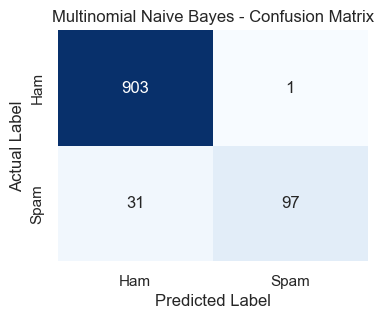


========== Support Vector Machine (Linear) ==========
Accuracy:  0.9767 | Precision: 0.9815 | Recall: 0.8281 | F1-Score: 0.8983


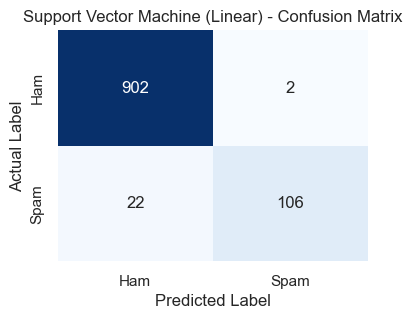

In [21]:
# Initialize enterprise-grade models
models = {
    "Multinomial Naive Bayes": MultinomialNB(), 
    "Support Vector Machine (Linear)": SVC(kernel='linear', random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*10} {name} {'='*10}")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"Accuracy:  {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")
    
    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

## Strategic Discussion: Precision vs. Recall
In the context of enterprise spam detection, the balance between Precision and Recall is critical.

* **Recall** ensures we catch as much spam as possible. High recall means a cleaner inbox.
* **Precision** ensures we do not accidentally label legitimate emails (ham) as spam. 

For commercial spam filters, **Precision is usually prioritized over Recall**. It is a minor inconvenience for a user to manually delete a spam email (low recall), but it is a massive failure if a critical business contract or flight itinerary is routed to the spam folder (low precision).

## Step 7: Bonus - Top Words Visualization
To wrap up our analysis, we will extract the top 10 most frequently used terms in both Spam and Ham messages to verify that our preprocessing and TF-IDF logic align with human intuition.

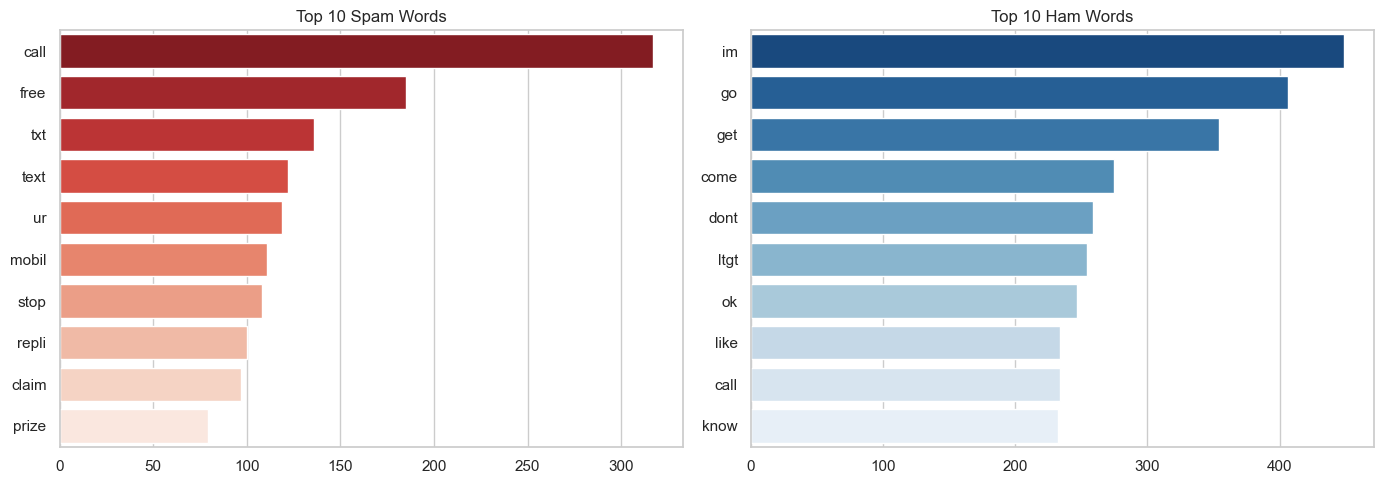

In [22]:
# robust frequency analysis
def get_top_n_words(corpus, n=10):
    vec = CountVectorizer().fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get top words
top_spam = get_top_n_words(df[df['label'] == 'spam']['cleaned_message'], 10)
top_ham = get_top_n_words(df[df['label'] == 'ham']['cleaned_message'], 10)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=[w[1] for w in top_spam], y=[w[0] for w in top_spam], palette='Reds_r', ax=axes[0])
axes[0].set_title('Top 10 Spam Words')

sns.barplot(x=[w[1] for w in top_ham], y=[w[0] for w in top_ham], palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 10 Ham Words')

plt.tight_layout()
plt.show()

# Project Conclusion & Business Analysis

After successfully building and executing our end-to-end NLP pipeline, we can draw several critical insights regarding the data, the preprocessing methodology, and model performance.

## 1. Data Distribution & EDA Insights
Based on our exploratory data analysis, the dataset exhibits patterns that are highly characteristic of real-world communication networks:
* **Severe Class Imbalance:** The data is approximately **87.5% Ham** and **12.4% Spam**. This reinforces the necessity of using stratified sampling during our train/test split to ensure our models trained on representative data.
* **The Length Feature:** The Message Length Distribution plot revealed a significant behavioral insight. Normal messages (ham) typically peak early around 30–50 characters. In contrast, spam messages have a distinct peak around 150 characters. Spammers tend to maximize their character limits to pack in links, phone numbers, and fake prize details.

## 2. Preprocessing Validation
Our custom `TextPreprocessor` pipeline effectively normalized the raw text data:
* **Punctuation & Noise Removal:** Special characters and numbers were successfully stripped, preventing the model from learning arbitrary symbols.
* **Stemming:** Words were aggressively reduced to their linguistic roots (e.g., "crazy" to "crazi", "entry" to "entri"). This crucial step minimized our feature space, reducing computational load and preventing the TF-IDF vectorizer from treating variations of the same word as entirely different features.

## 3. Model Evaluation & Business Impact
We evaluated two enterprise-grade models: Multinomial Naive Bayes and a Support Vector Machine (SVM). 

* **Multinomial Naive Bayes:** Achieved a phenomenal **Precision of 98.98%**. Looking at the confusion matrix, it only misclassified 1 legitimate message as spam (False Positive). However, its Recall was lower (75.78%), meaning 31 spam messages slipped into the inbox (False Negatives).
* **Support Vector Machine (Linear):** The SVM outperformed the baseline. It maintained an incredible **Precision of 98.15%** (only 2 False Positives) but drastically improved **Recall to 82.81%**. It caught 106 spam messages compared to Naive Bayes' 97.

## 4. The Final Verdict
For an enterprise email or SMS system, **the Support Vector Machine (SVM) is the winning model**. 

In spam detection, business logic dictates that Precision is prioritized over Recall (a missed work email is catastrophic, whereas manually deleting a spam email is a minor nuisance). The SVM successfully caught significantly more spam (higher recall) while only sacrificing a negligible fraction of a percent in precision. This ensures the user's primary inbox stays clean without risking the loss of critical, legitimate communications.